In [5]:
import torch
from models import SimpleNN
from main import test_loader, epochs
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

epochs = 20
acc_saver = []
for epoch in range(epochs):

    loss_saver = []
    all_preds = []
    all_labels = []

    checkpoint = torch.load(f"./model_checkpoints/mnist_simple_nn_model_epoch={epoch}.pth")
    model = SimpleNN()
    model.load_state_dict(checkpoint)
    model.eval()

    with torch.no_grad():
        for x, y in test_loader:
            y_pred = model(x)
            digit_pred = torch.argmax(y_pred, dim=1)

            all_preds.extend(digit_pred.numpy())
            all_labels.extend(y.numpy())

    accuracy = accuracy_score(all_preds, all_labels)
    acc_saver.append(accuracy)
    print(f"Epoch {epoch} accuracy: {accuracy}")

Epoch 0 accuracy: 0.9049
Epoch 1 accuracy: 0.9154
Epoch 2 accuracy: 0.9325
Epoch 3 accuracy: 0.9415
Epoch 4 accuracy: 0.9488
Epoch 5 accuracy: 0.9545
Epoch 6 accuracy: 0.9599
Epoch 7 accuracy: 0.9578
Epoch 8 accuracy: 0.9647
Epoch 9 accuracy: 0.9654
Epoch 10 accuracy: 0.9691
Epoch 11 accuracy: 0.9647
Epoch 12 accuracy: 0.9709
Epoch 13 accuracy: 0.9693
Epoch 14 accuracy: 0.9731
Epoch 15 accuracy: 0.9721
Epoch 16 accuracy: 0.9737
Epoch 17 accuracy: 0.9723
Epoch 18 accuracy: 0.9758
Epoch 19 accuracy: 0.975


Text(0.5, 1.0, 'Accuracies')

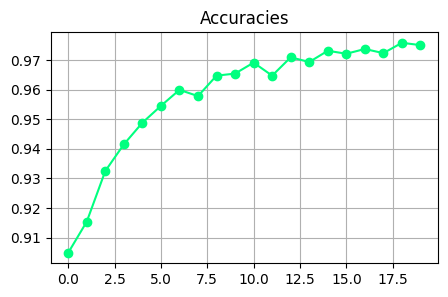

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(acc_saver, color="SpringGreen", label="accuracies", marker='o', linestyle='-')
plt.grid()
plt.title("Accuracies")